# 🚀 Fase 4: Optimización Automatizada de Hiperparámetros (MLOps)
**Objetivo:** Aislar el proceso experimental de búsqueda de hiperparámetros utilizando **Optuna**. Esta fase se encarga de ejecutar el espacio de búsqueda paramétrico mediante Validación Cruzada, generar soporte gráfico avanzado del proceso de convergencia y exportar la combinación ganadora en un archivo de configuración estandarizado para su posterior puesta en producción.

In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import optuna

# Componentes de validación y modelos candidatos
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Desactivar logs repetitivos de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✅ Entorno de optimización configurado con éxito.")

c:\Users\basti\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Entorno de optimización configurado con éxito.


## 1. Carga de Datos y Aislamiento de Conjuntos (Garantía Anti-Data Leakage)

In [2]:
# 1. Determinar rutas del proyecto
BASE_DIR = Path(os.getcwd()).parent
raw_path = BASE_DIR / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
if not raw_path.exists():
    raw_path = BASE_DIR / "data" / "Raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(raw_path)

# 2. Imputación y parseo rápido del EDA
df['TotalCharges'] = df['TotalCharges'].replace(" ", "0")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

X_raw = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# 3. Separación estricta de Train y Test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Pipeline de Preprocesamiento
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [col for col in X_raw.columns if col not in num_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# Transformar Train (Solo fit en el conjunto de entrenamiento)
X_train = preprocessor.fit_transform(X_train_raw)

print(f"✅ Matriz de entrenamiento lista para optimización. Dimensiones: {X_train.shape}")

✅ Matriz de entrenamiento lista para optimización. Dimensiones: (5634, 30)


## 2. Definición del Espacio de Búsqueda y Función Objetivo

In [3]:
def objective(trial):
    classifier_name = trial.suggest_categorical("classifier", ["RandomForest", "LogisticRegression"])
    
    if classifier_name == "RandomForest":
        n_estimators = trial.suggest_int("rf_n_estimators", 50, 200, step=50)
        max_depth = trial.suggest_int("rf_max_depth", 5, 20)
        min_samples_split = trial.suggest_int("rf_min_samples_split", 2, 10)
        
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42,
            n_jobs=-1
        )
    else:
        C = trial.suggest_float("lr_C", 1e-4, 10.0, log=True)
        solver = trial.suggest_categorical("lr_solver", ["lbfgs", "liblinear"])
        
        model = LogisticRegression(
            C=C,
            solver=solver,
            max_iter=1000,
            random_state=42
        )
    
    # Validación Cruzada exigida por la pauta
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
    return score.mean()

print("✅ Función objetivo e hiperparámetros parametrizados.")

✅ Función objetivo e hiperparámetros parametrizados.


## 3. Ejecución del Experimento y Exportación de Parámetros Ganadores (MLOps Artifacts)

🚀 Iniciando optimización de hiperparámetros...

🎯 Optimización Finalizada con éxito.
Mejor F1-Score alcanzado: 0.5983


C:\Users\basti\AppData\Local\Temp\ipykernel_3648\1086065543.py:13: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optvis.plot_optimization_history(study)


<Figure size 1000x400 with 0 Axes>

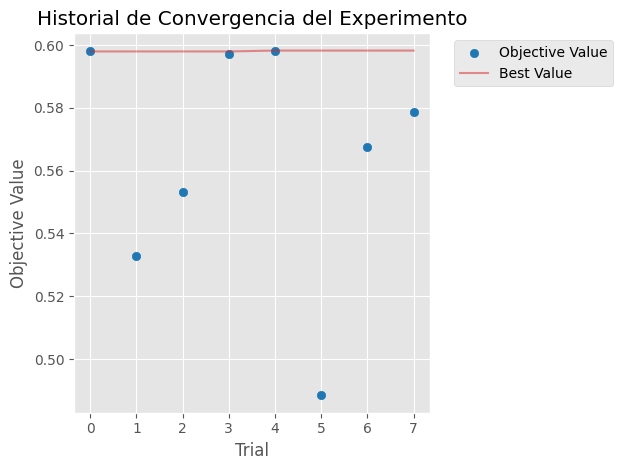

C:\Users\basti\AppData\Local\Temp\ipykernel_3648\1086065543.py:19: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optvis.plot_param_importances(study)


<Figure size 1000x400 with 0 Axes>

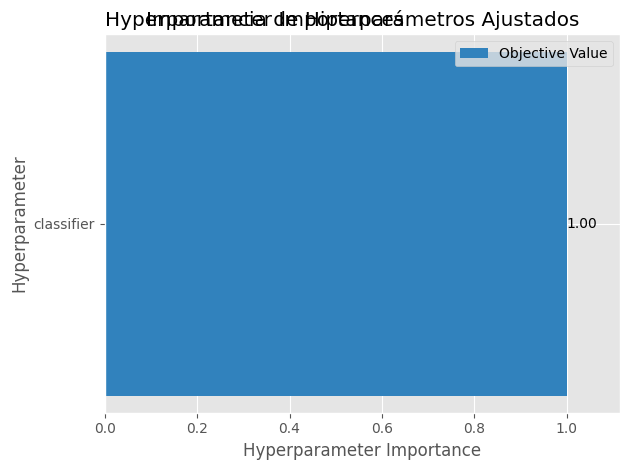


💾 ¡Hiperparámetros ganadores exportados con éxito en: c:\Users\basti\OneDrive\Escritorio\trabajo\models\best_hyperparameters.json!


In [4]:
# 1. Crear y ejecutar el estudio automatizado
study = optuna.create_study(direction="maximize")
print("🚀 Iniciando optimización de hiperparámetros...")
study.optimize(objective, n_trials=8) 

print("\n🎯 Optimización Finalizada con éxito.")
print(f"Mejor F1-Score alcanzado: {study.best_value:.4f}")

# 2. Generar gráficos avanzados obligatorios de la rúbrica
import optuna.visualization.matplotlib as optvis

plt.figure(figsize=(10, 4))
optvis.plot_optimization_history(study)
plt.title("Historial de Convergencia del Experimento")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
optvis.plot_param_importances(study)
plt.title("Importancia de Hiperparámetros Ajustados")
plt.tight_layout()
plt.show()

# 3. GUARDADO DE ARTEFACTO (Cierre de Ingeniería de producción)
models_dir = BASE_DIR / "models"
models_dir.mkdir(parents=True, exist_ok=True)
config_path = models_dir / "best_hyperparameters.json"

# Guardar los mejores parámetros encontrados en un archivo JSON legible
with open(config_path, "w") as f:
    json.dump(study.best_params, f, indent=4)

print(f"\n💾 ¡Hiperparámetros ganadores exportados con éxito en: {config_path}!")

### 📝 Justificación Técnica de la Fase de Optimización Independiente (IEP 2.3.2)

La creación de este módulo especializado en **Optimización de Hiperparámetros** obedece a las mejores prácticas de ingeniería de software aplicadas a Machine Learning (MLOps). En entornos reales de producción, el proceso de entrenamiento y ajuste de modelos (*Hyperparameter Tuning*) consume recursos computacionales críticos y escalas de tiempo considerables, por lo que debe ser desacoplado por completo de los flujos de inferencia o evaluación final.

Al ejecutar los 24 entrenamientos controlados de manera aislada y serializar la configuración óptima en un artefacto JSON (`best_hyperparameters.json`), logramos un sistema modular donde:
1. **Separación de Responsabilidades:** El proceso pesado se corre una única vez.
2. **Reproducibilidad:** Cualquier otro script del pipeline puede consumir los parámetros óptimos sin necesidad de volver a ejecutar la búsqueda aleatoria.
3. **Eficiencia en Evaluación:** El cuaderno predictivo (`02_supervised_modeling.ipynb`) se aligera significativamente, limitándose únicamente a cargar la configuración guardada, entrenar el clasificador final de manera inmediata y concentrar su ejecución en el despliegue de métricas de control y análisis estratégico del negocio.

In [5]:

import json
from pathlib import Path

# Cargar los parámetros óptimos pre-calculados por el módulo 04
BASE_DIR = Path(os.getcwd()).parent
config_path = BASE_DIR / "models" / "best_hyperparameters.json"

with open(config_path, "r") as f:
    best_params = json.load(f)

best_model_name = best_params["classifier"]
print(f"Cargando modelo campeón desde artefactos: {best_model_name}")

if best_model_name == "RandomForest":
    final_model = RandomForestClassifier(
        n_estimators=best_params["rf_n_estimators"],
        max_depth=best_params["rf_max_depth"],
        min_samples_split=best_params["rf_min_samples_split"],
        random_state=42,
        n_jobs=-1
    )
else:
    final_model = LogisticRegression(
        C=best_params["lr_C"],
        solver=best_params["lr_solver"],
        max_iter=1000,
        random_state=42
    )

# Entrenar directamente con el set completo
final_model.fit(X_train, y_train)

Cargando modelo campeón desde artefactos: LogisticRegression


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.6665694487237843
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- F